# Estimarea Pretului pentru Procesoare

In [352]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from IPython.display import Markdown

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb

from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use("ggplot")
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

Pentru [df_bench](../data/CPU_benchmark_v4.csv) datele au fost descarcate din: [CPU Benchmarks Compilation](https://www.kaggle.com/datasets/alanjo/cpu-benchmarks)

In [353]:
df = pd.read_csv(r"..\data\CPU_benchmark_v4.csv")

# df.head(20)
# df.isna().sum()
# df.shape
# df.dtypes
# df.describe()

# df["TDP"].value_counts().head(10).plot(kind="barh")
# df["price"].plot(kind="hist", bins=100)

# df["price"].plot(kind="kde") 
# sns.pairplot(df, vars=[""])

# df.plot(kind="scatter", x="TDP", y="price", alpha=0.7)

# Curatarea datelor
Setul de date descarcat din [CPU Benchmarks Compilation](https://www.kaggle.com/datasets/alanjo/cpu-benchmarks) are nevoie de urmatoarele curatari:
-   campul `price` este evaluat in dolari, asa ca trebuie sa convertim din USD in RON.
-   din cauza ca producatorul se afla in numele procesorului, se va creia un camp nou numit `manufacturer` in care va fi separat.
-   incat campurile derivate nu ne intereseaza din setul de date (de ex. campul `cpuValue` este format din `cpuMark / price`) acestea vor fi scoase.
-   campurile care nu contin date in `price` vor fi folosite ca date pentru testarea predictiei, lafel cu procesoarele din fisierul [CPU_r23_v2.csv](../data/CPU_r23_v2.csv)


In [354]:
RATA_RON_USD = 4.39

df['manufacturer'] = df['cpuName'].apply(lambda x: str(x).split()[0] if pd.notnull(x) else 'Unknown')
df['price'] = df['price'] * RATA_RON_USD
df['log_price'] = np.log1p(df['price'])

def extract_series(name):
    name = str(name); l = name.lower()
    if 'ryzen' in l:
        if 'threadripper' in l: return 'Threadripper'
        for s in ['9','7','5','3']:
            if f'ryzen {s}' in l or f'ryzen\u2122 {s}' in l: return f'Ryzen_{s}'
        return 'Ryzen'
    for s in ['i9','i7','i5','i3']:
        if s in l: return s.upper()
    if 'xeon' in l:
        if 'gold' in l: return 'Xeon_Gold'
        if 'platinum' in l: return 'Xeon_Platinum'
        if 'silver' in l: return 'Xeon_Silver'
        return 'Xeon'
    if 'epyc' in l: return 'EPYC'
    if 'pentium' in l: return 'Pentium'
    if 'celeron' in l: return 'Celeron'
    if 'athlon' in l: return 'Athlon'
    if 'apple' in l or 'm1' in l or 'm2' in l: return 'Apple'
    if 'hygon' in l: return 'Hygon'
    return 'Other'

def extract_gen(name):
    name = str(name)
    m = re.search(r'(?:i[3-9]-)?(\d{4,5})[A-Za-z]*', name)
    if m:
        num = int(m.group(1)); s = str(num)
        if len(s) == 5: return int(s[:2])
        elif len(s) == 4: return int(s[:2]) if s[0] == '1' else int(s[0])
    return -1

def extract_tier(name):
    name = str(name); l = name.lower()
    if 'i9' in l or 'ryzen 9' in l or 'threadripper' in l: return 9
    if 'i7' in l or 'ryzen 7' in l: return 7
    if 'xeon platinum' in l: return 9
    if 'i5' in l or 'ryzen 5' in l or 'xeon gold' in l: return 5
    if 'i3' in l or 'ryzen 3' in l: return 3
    if 'epyc' in l: return 8
    if 'xeon' in l: return 4
    if 'pentium' in l: return 2
    if 'athlon' in l or 'celeron' in l: return 1
    return 0

df['series'] = df['cpuName'].apply(extract_series)
df['gen'] = df['cpuName'].apply(extract_gen)
df['tier'] = df['cpuName'].apply(extract_tier)

df = df[[
    'manufacturer',
    'series',
    'gen',
    'tier',
    'log_price',
    'price', 
    'cpuMark', 
    'threadMark', 
    'TDP', 
    'cores', 
    'testDate', 
    'category',
    ]].copy()

# Analiza exploratorie
Din cauza ca diferenta intre media preturilor si mediana acestora este mare (706.79 vs. 1938) sugereaza ca datele sunt distribuite asimetric spre stanga. Din acest motiv in model se va aplica log() pe pret pentru al aduce mai aproape de o curba gaussiana.

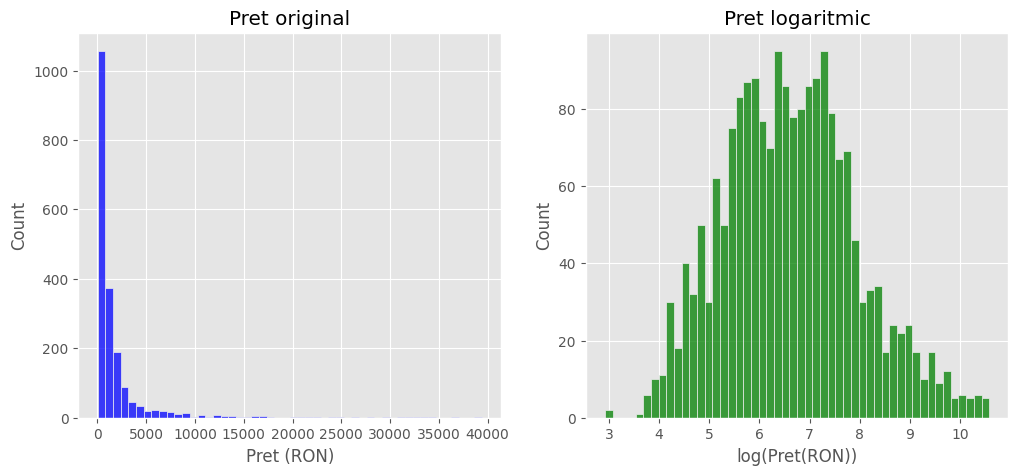

In [355]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['price'], bins=50, ax=axes[0], color='blue')
axes[0].set_title('Pret original')
axes[0].set_xlabel('Pret (RON)')

sns.histplot(df['log_price'], bins=50, ax=axes[1], color='green')
axes[1].set_title('Pret logaritmic')
axes[1].set_xlabel('log(Pret(RON))')

plt.show() # diferenta intre graficul original si cel logaritmic

### Correlatie
Pentru a putea afla care factori influenteaza cel mai tare pretul, se va observa urmatorul heatmap.
Din acest heatmap putem extrage urmatoarele rezultate:
-   Pretul este cel mai tare corelat cu scorul de performanta din benchmark, care este un rezultat asteptat.
-   Numarul de nuclee are o corelatie puternica cu pretul, mai puternica ca `threadMark` (performanta pe un singur nucleu).
-   Intre TPD si threadMark corelatia este destul de mica, asa ca mai multa putere nu inseamna cresterea performantei pe un singur nucleu.

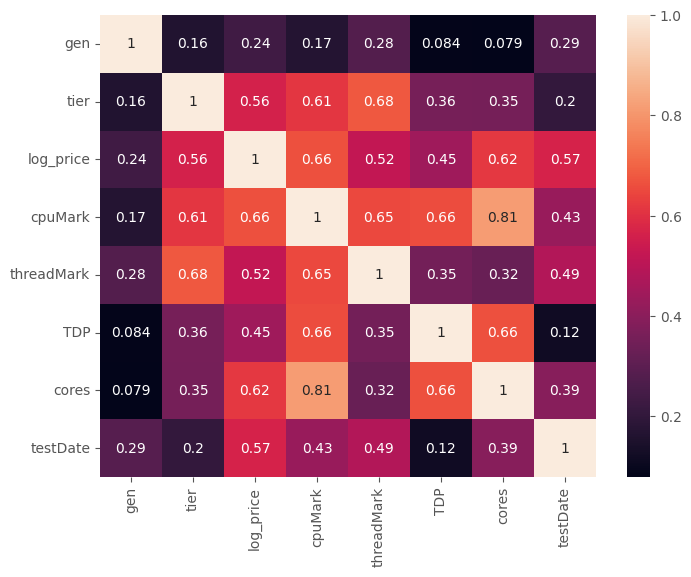

                 gen      tier  log_price   cpuMark  threadMark       TDP  \
gen         1.000000  0.158453   0.235964  0.166554    0.277956  0.083631   
tier        0.158453  1.000000   0.562811  0.612524    0.678369  0.356325   
log_price   0.235964  0.562811   1.000000  0.664349    0.520090  0.445253   
cpuMark     0.166554  0.612524   0.664349  1.000000    0.651022  0.657544   
threadMark  0.277956  0.678369   0.520090  0.651022    1.000000  0.349236   
TDP         0.083631  0.356325   0.445253  0.657544    0.349236  1.000000   
cores       0.079041  0.353002   0.618283  0.814717    0.323995  0.664270   
testDate    0.286152  0.204210   0.566567  0.428139    0.485485  0.117902   

               cores  testDate  
gen         0.079041  0.286152  
tier        0.353002  0.204210  
log_price   0.618283  0.566567  
cpuMark     0.814717  0.428139  
threadMark  0.323995  0.485485  
TDP         0.664270  0.117902  
cores       1.000000  0.393733  
testDate    0.393733  1.000000  


In [356]:
plt.figure(figsize=(8, 6))
df_log_price = df.drop('price', axis=1) # pentru ca folosim pretul logaritmic, scoatem pretul original
sns.heatmap(data=df_log_price.corr(numeric_only=True), annot=True)
plt.show()

print(df_log_price.corr(numeric_only=True))


# Feature Engineering

## 1. Ingineria caracteristicilor
Vom crea caracteristici noi care pot ajuta modelul să facă predicții mai bune:
-   `perf_per_core` — performanta multi-core impartita la numarul de nuclee, care ne arata eficienta fiecarui nucleu.
-   `perf_per_watt` — eficienta energetica a procesorului
-   `cores_rank` — gruparea procesoarelor în categorii de nuclee (low/mid/high/ultra).
-   `manufacturer_encoded` — codificarea producătorului ca variabilă numerică.
-   `category_encoded` — codificarea categoriei (Desktop/Laptop/Server) ca variabilă numerică.

In [357]:
df_fe = df_log_price.copy()

# 1. Performanta per nucleu
df_fe['perf_per_core'] = df_fe['cpuMark'] / df_fe['cores']

# 2. Performanta per watt
df_fe['perf_per_watt'] = df_fe['cpuMark'] / df_fe['TDP'].replace(0, np.nan)

def bin_cores(c):
    if c <= 4:
        return 0  # low
    elif c <= 8:
        return 1  # mid
    elif c <= 16:
        return 2  # high
    else:
        return 3  # ultra

df_fe['core_rank'] = df_fe['cores'].apply(bin_cores)
df_fe['log_cores'] = np.log1p(df_fe['cores'])

# Adaug pre\u021bul \u00eenapoi pentru filtrare
df_fe['price'] = df['price']

# Elimin outlierii de pre\u021b extremi (< 50 RON = ~$11)
df_fe = df_fe[df_fe['price'] >= 50].copy()
print(f'R\u00e2nduri dup\u0103 filtrare pre\u021b < 50 RON: {len(df_fe)}')

le_series = LabelEncoder()
df_fe['series_encoded'] = le_series.fit_transform(df_fe['series'])

le_cat = LabelEncoder()
df_fe['category_encoded'] = le_cat.fit_transform(df_fe['category'])
df_fe = df_fe.drop('category', axis=1)

display(df_fe.head(10))

Rânduri după filtrare preț < 50 RON: 1954


,manufacturer,series,gen,tier,log_price,cpuMark,threadMark,TDP,cores,testDate,perf_per_core,perf_per_watt,core_rank,log_cores,price,series_encoded,category_encoded
1,AMD,EPYC,7,8,10.374989,88338,2635,280.0,64,2021,1380.281250,315.492857,3,4.174387,32046.9561,3,8
3,AMD,EPYC,7,8,10.341562,85861,2727,225.0,64,2021,1341.578125,381.604444,3,4.174387,30993.4000,3,8
4,AMD,Threadripper,3,9,10.305213,83971,2626,280.0,64,2020,1312.046875,299.896429,3,4.174387,29887.0322,14,0
5,AMD,Threadripper,3,9,10.515306,81568,2569,280.0,64,2020,1274.500000,291.314286,3,4.174387,36874.6391,14,0
8,AMD,EPYC,7,8,10.078143,76455,2695,225.0,48,2021,1592.812500,339.800000,3,3.891820,23815.7061,3,8
9,AMD,EPYC,7,8,9.773436,71646,2097,200.0,64,2020,1119.468750,358.230000,3,4.174387,17560.0000,3,8
10,AMD,EPYC,7,8,10.306537,71576,2054,225.0,64,2021,1118.375000,318.115556,3,4.174387,29926.6300,3,8
11,AMD,EPYC,7,8,10.005724,68749,2145,225.0,64,2019,1074.203125,305.551111,3,4.174387,22151.8961,3,8
14,AMD,EPYC,7,8,9.691145,67748,2155,225.0,48,2021,1411.416667,301.102222,3,3.891820,16172.7600,3,8
15,AMD,EPYC,7,8,9.485439,67144,2742,225.0,32,2021,2098.250000,298.417778,3,3.496508,13165.6100,3,8


### Distributia caracteristicilor noi
Verificam cum sunt distribuite noile caracteristici create.

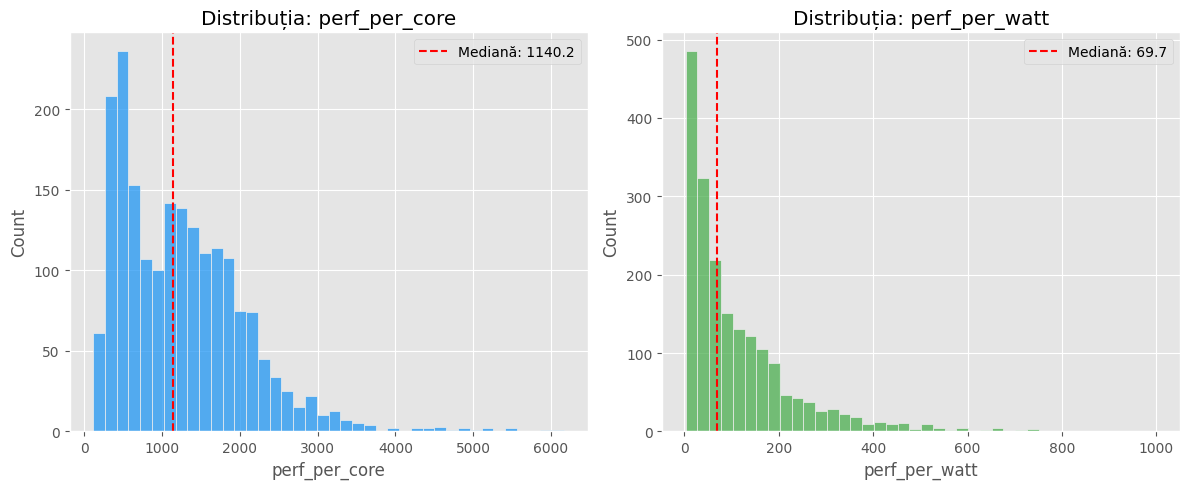

In [358]:
new_features = ['perf_per_core', 'perf_per_watt']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, feat in enumerate(new_features):
    data = df_fe[feat].dropna()
    sns.histplot(data, bins=40, ax=axes[i], color=['#2196F3', '#4CAF50', '#FF9800'][i])
    axes[i].set_title(f'Distribuția: {feat}')
    axes[i].set_xlabel(feat) 
    median_val = data.median()
    axes[i].axvline(median_val, color='red', linestyle='--', label=f'Mediană: {median_val:.1f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

## 2. Calcularea și analiza corelațiilor
### 2.1 Corelația Pearson si Spearman

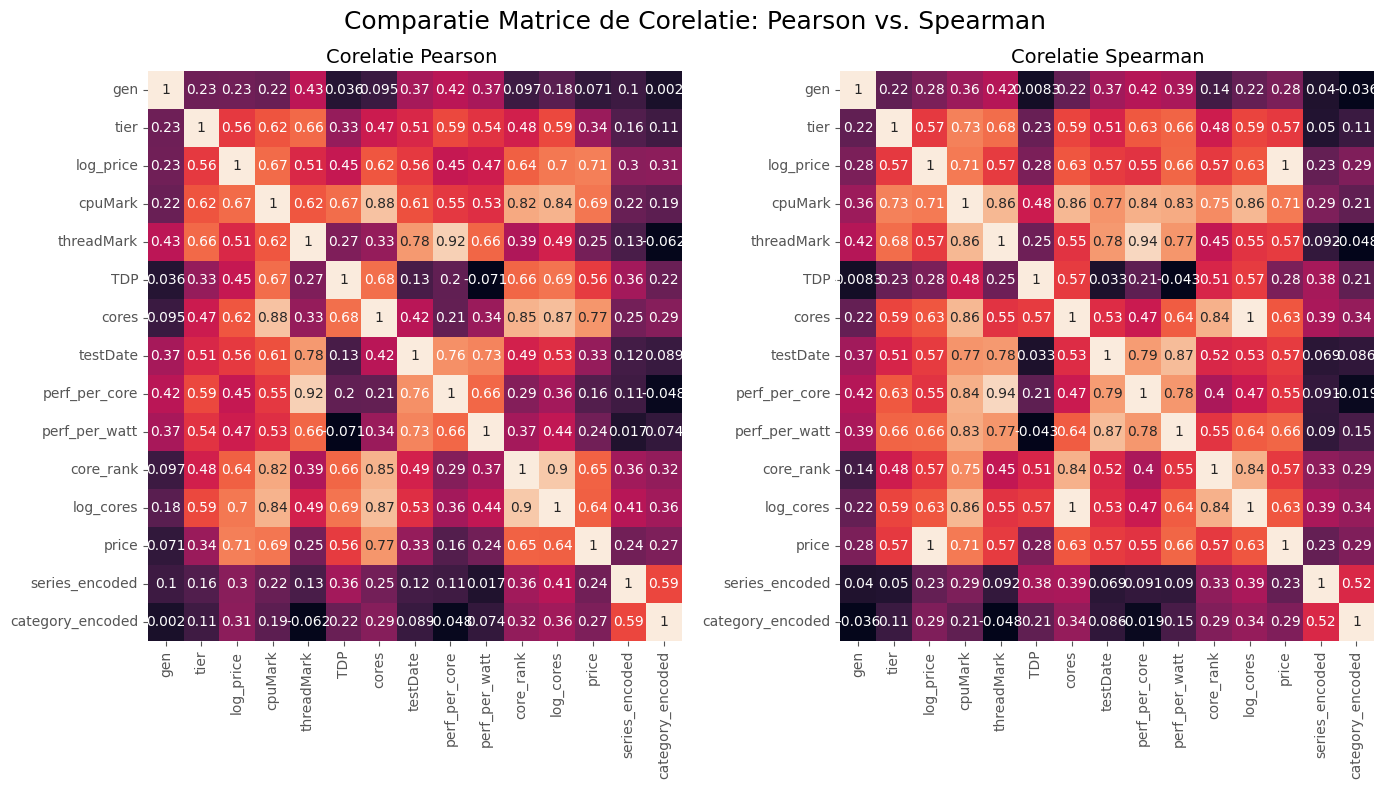

,Pearson,Spearman,Diff
price,0.711927,1.000000,0.288073
perf_per_watt,0.472591,0.662121,0.189530
TDP,0.450224,0.283633,0.166591
perf_per_core,0.449835,0.551762,0.101927
core_rank,0.642068,0.566164,0.075903
series_encoded,0.301190,0.225675,0.075515
log_cores,0.696581,0.630215,0.066366
threadMark,0.511951,0.571090,0.059139
gen,0.234476,0.282896,0.048420
cpuMark,0.667290,0.706071,0.038781


In [359]:
df_numeric = df_fe.dropna()

corr_pearson = df_numeric.corr(method='pearson', numeric_only=True)
corr_spearson = df_numeric.corr(method='spearman', numeric_only=True)


fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.heatmap(corr_pearson, annot=True, ax=axes[0], cbar=False)
axes[0].set_title('Corelatie Pearson ', fontsize=14)

sns.heatmap(corr_spearson, annot=True, ax=axes[1], cbar=False)
axes[1].set_title('Corelatie Spearman', fontsize=14)

fig.suptitle('Comparatie Matrice de Corelatie: Pearson vs. Spearman', fontsize=18)

plt.tight_layout()
plt.show()


comparison = pd.DataFrame({
    'Pearson': corr_pearson['log_price'].drop('log_price'),
    'Spearman': corr_spearson['log_price'].drop('log_price'),
    'Diff': abs(corr_pearson['log_price'].drop('log_price') - corr_spearson['log_price'].drop('log_price'))
}).sort_values('Diff', ascending=False)

display(comparison)

### 2.3 Vizualizarea relatiilor cu variabila tinta

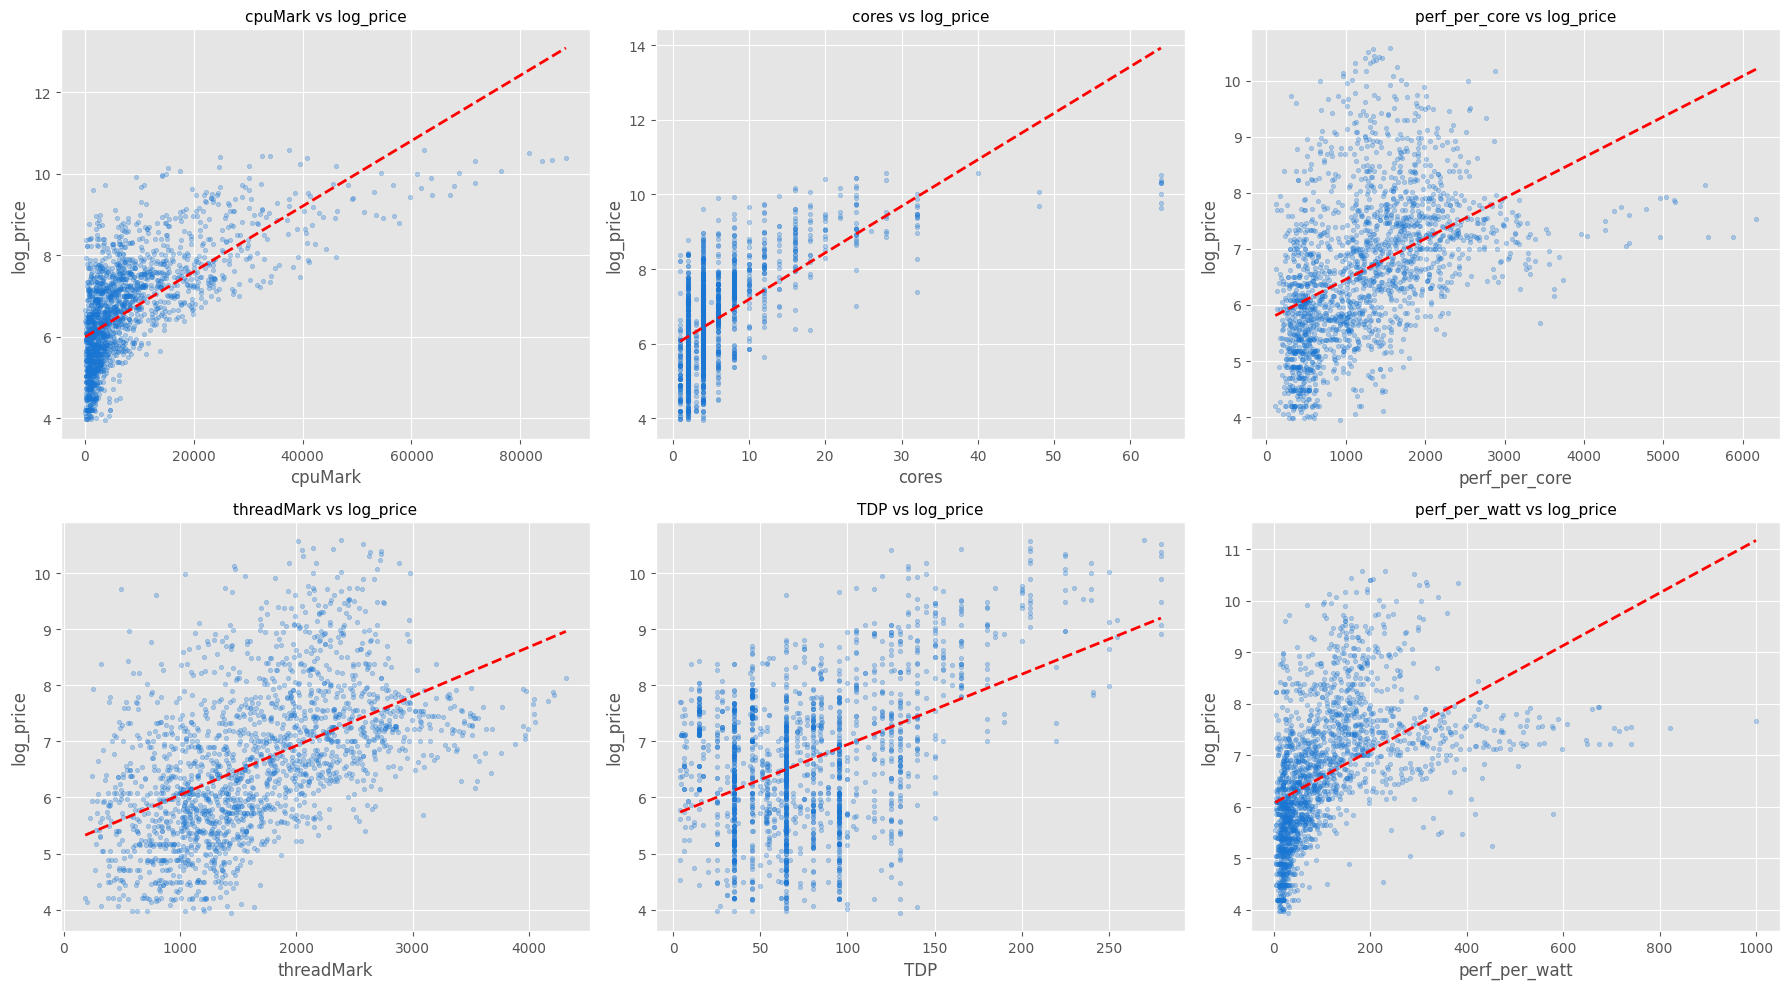

In [360]:

top_features = ['cpuMark', 'cores', 'perf_per_core', 'threadMark', 'TDP', 'perf_per_watt']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    data = df_fe[[feat, 'log_price']].dropna()
    axes[i].scatter(data[feat], data['log_price'], alpha=0.3, s=10, color='#1976D2')
    
    # Linia de regresie
    z = np.polyfit(data[feat], data['log_price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(data[feat].min(), data[feat].max(), 100)
    axes[i].plot(x_line, p(x_line), color='red', linewidth=2, linestyle='--')
    
    r, p_val = stats.pearsonr(data[feat], data['log_price'])
    axes[i].set_title(f'{feat} vs log_price', fontsize=11)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('log_price')

plt.tight_layout()
plt.show()

## 3. Importanța caracteristicilor
### 3.1 Importanta caracteristicilor la regresia Ridge.

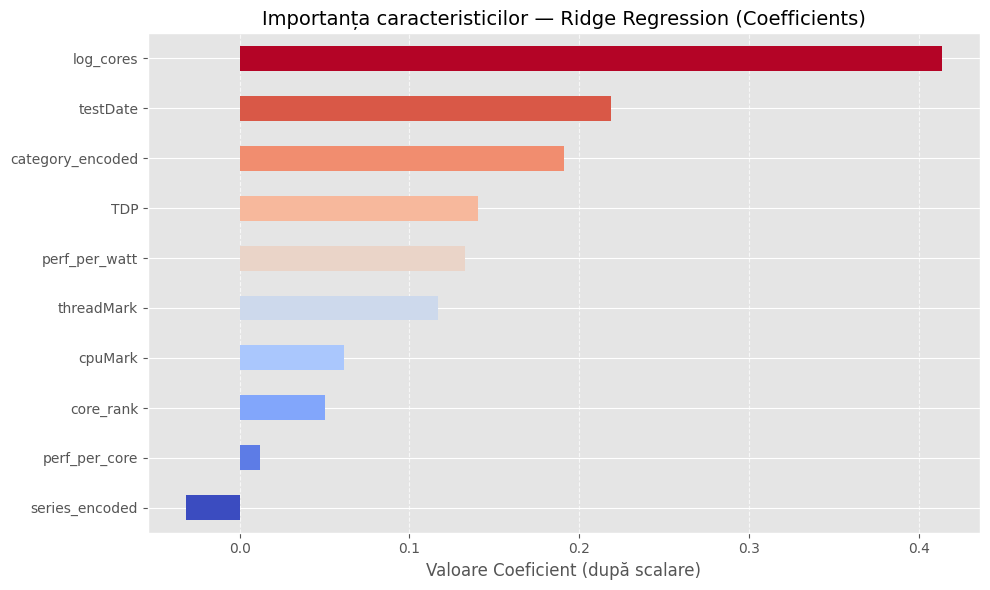

In [361]:
feature_cols = ['cpuMark', 'threadMark', 'TDP',
                'perf_per_core', 'perf_per_watt',
                'core_rank', 'log_cores',
                'series_encoded', 'category_encoded',
                'testDate']

df_model = df_fe.dropna()
X = df_model[feature_cols]
y = df_model['log_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=33550336
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

ridge = Ridge(alpha=1.0, random_state=33550336)
ridge.fit(X_train_s, y_train)


importances_ridge = pd.Series(ridge.coef_, index=feature_cols)
importances_ridge = importances_ridge.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = plt.cm.coolwarm(np.linspace(0, 1, len(importances_ridge))) 
importances_ridge.plot(kind='barh', color=colors)

plt.title('Importan\u021ba caracteristicilor \u2014 Ridge Regression (Coefficients)', fontsize=14)
plt.xlabel('Valoare Coeficient (dup\u0103 scalare)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 3.2 Importanta caracteristicilor la Random Forest

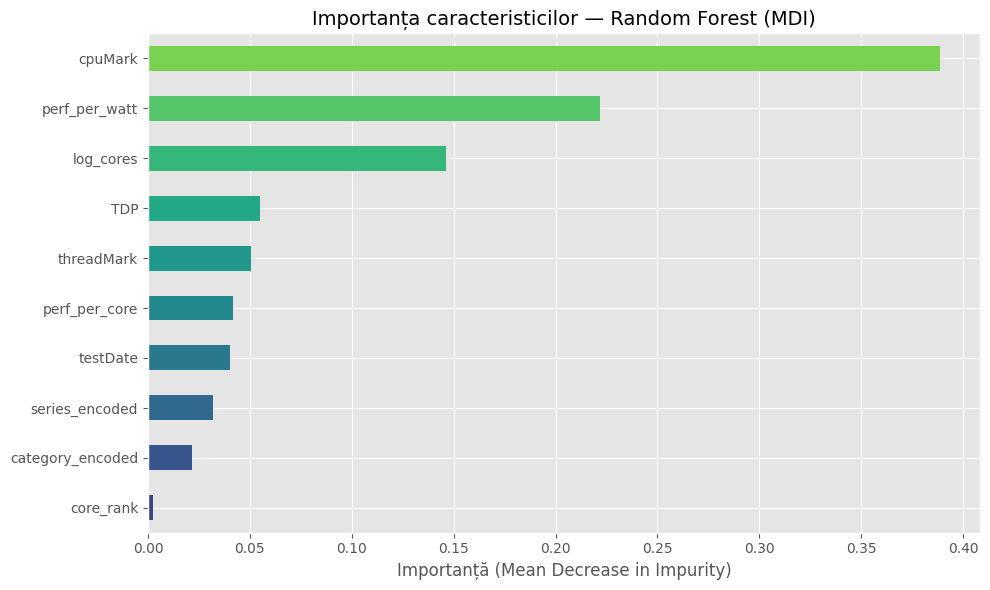

In [362]:
feature_cols = ['cpuMark', 'threadMark', 'TDP',
                'perf_per_core', 'perf_per_watt',
                'core_rank', 'log_cores',
                'series_encoded', 'category_encoded',
                'testDate']

df_model = df_fe.dropna()
X = df_model[feature_cols]
y = df_model['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=33550336)


rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,             
    min_samples_split=10,     
    min_samples_leaf=4,       
    random_state=33550336, 
    n_jobs=-1
)
rf.fit(X_train, y_train)

importances_mdi = pd.Series(rf.feature_importances_, index=feature_cols)
importances_mdi = importances_mdi.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(importances_mdi)))
importances_mdi.plot(kind='barh', color=colors)
plt.title('Importan\u021ba caracteristicilor \u2014 Random Forest (MDI)', fontsize=14)
plt.xlabel('Importan\u021b\u0103 (Mean Decrease in Impurity)')
plt.tight_layout()
plt.show()


# 3.3 Importanta caracteristilor la Gradient Boost

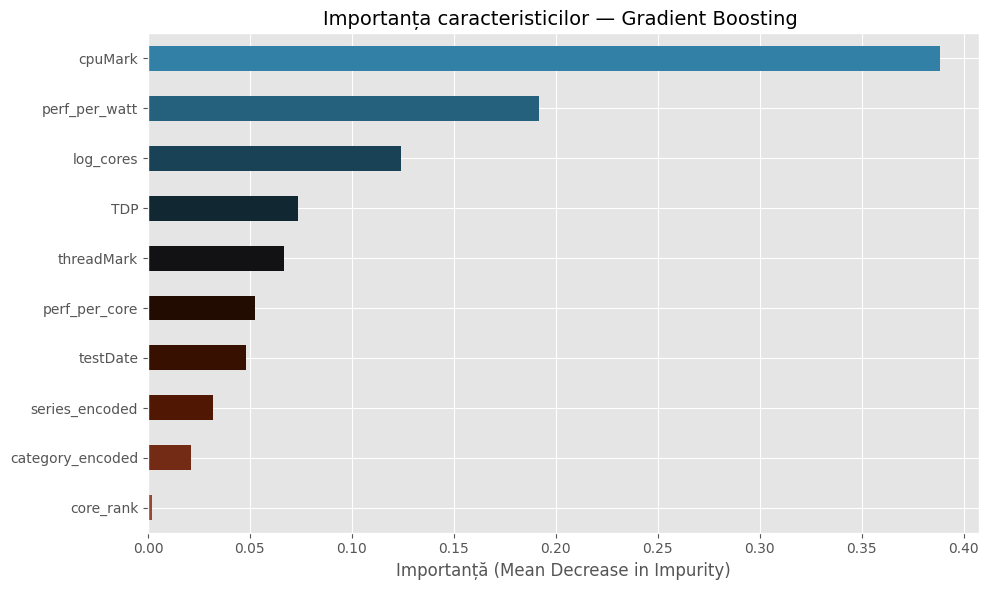

In [363]:
feature_cols = ['cpuMark', 'threadMark', 'TDP',
                'perf_per_core', 'perf_per_watt',
                'core_rank', 'log_cores',
                'series_encoded', 'category_encoded',
                'testDate']

df_model = df_fe.dropna()
X = df_model[feature_cols]
y = df_model['log_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=33550336
)

gb = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=33550336
)

gb.fit(X_train, y_train)

importances_gb = pd.Series(gb.feature_importances_, index=feature_cols)
importances_gb = importances_gb.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = plt.cm.berlin_r(np.linspace(0.2, 0.8, len(importances_gb)))
importances_gb.plot(kind='barh', color=colors)
plt.title('Importan\u021ba caracteristicilor \u2014 Gradient Boosting ', fontsize=14)
plt.xlabel('Importan\u021b\u0103 (Mean Decrease in Impurity)')
plt.tight_layout()
plt.show()

# 4. Implementarea algoritmilor
# 4.1 Regresia liniara Ridge

R² test: 0.5982
MAE: 1092.16 RON
RMSE: 3166.72 RON
MAPE: 79.65%


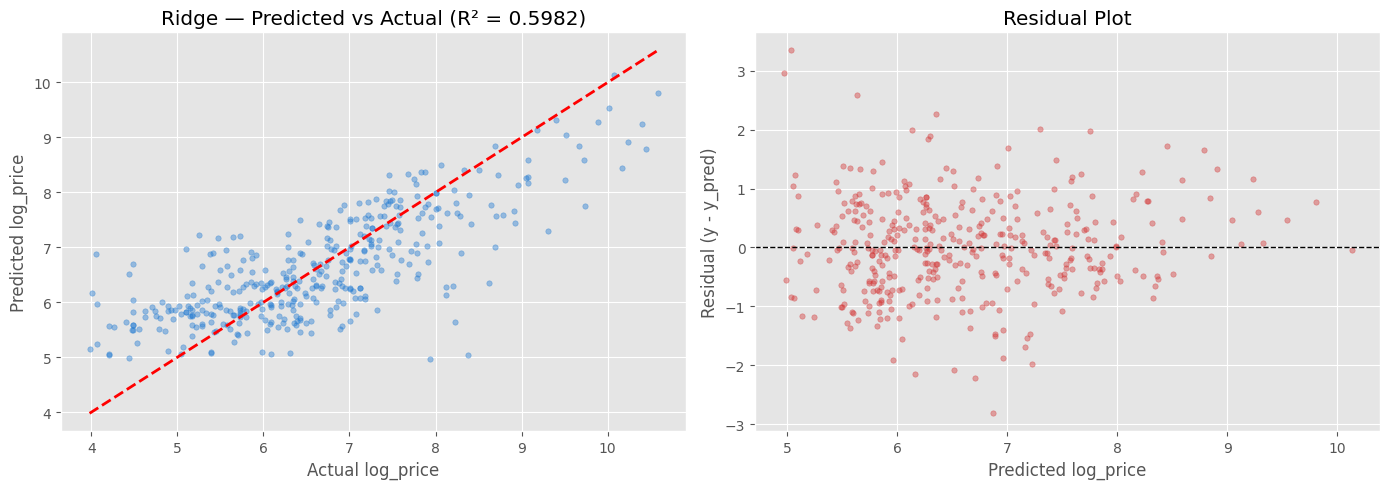

In [364]:
y_pred_log_ridge = ridge.predict(X_test_s)

r2_ridge = r2_score(y_test, y_pred_log_ridge)
mae_ridge = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_log_ridge))
rmse_ridge = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log_ridge)))
mape_ridge = np.mean(np.abs((np.expm1(y_test) - np.expm1(y_pred_log_ridge)) / np.expm1(y_test))) * 100

print(f'R² test: {r2_ridge:.4f}')
print(f'MAE: {mae_ridge:.2f} RON')
print(f'RMSE: {rmse_ridge:.2f} RON')
print(f'MAPE: {mape_ridge:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, y_pred_log_ridge, alpha=0.4, s=15, color='#1976D2')
min_val_ridge = min(y_test.min(), y_pred_log_ridge.min())
max_val_ridge = max(y_test.max(), y_pred_log_ridge.max())
axes[0].plot([min_val_ridge, max_val_ridge], [min_val_ridge, max_val_ridge], 'r--', linewidth=2)
axes[0].set_xlabel('Actual log_price')
axes[0].set_ylabel('Predicted log_price')
axes[0].set_title(f'Ridge — Predicted vs Actual (R² = {r2_ridge:.4f})')
residuals_ridge = y_test - y_pred_log_ridge
axes[1].scatter(y_pred_log_ridge, residuals_ridge, alpha=0.4, s=15, color='#D32F2F')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted log_price')
axes[1].set_ylabel('Residual (y - y_pred)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

# 4.2 Random Forest

Random Forest
R² test: 0.6938
MAE: 931.59 RON
RMSE: 2805.10 RON
MAPE: 65.60%


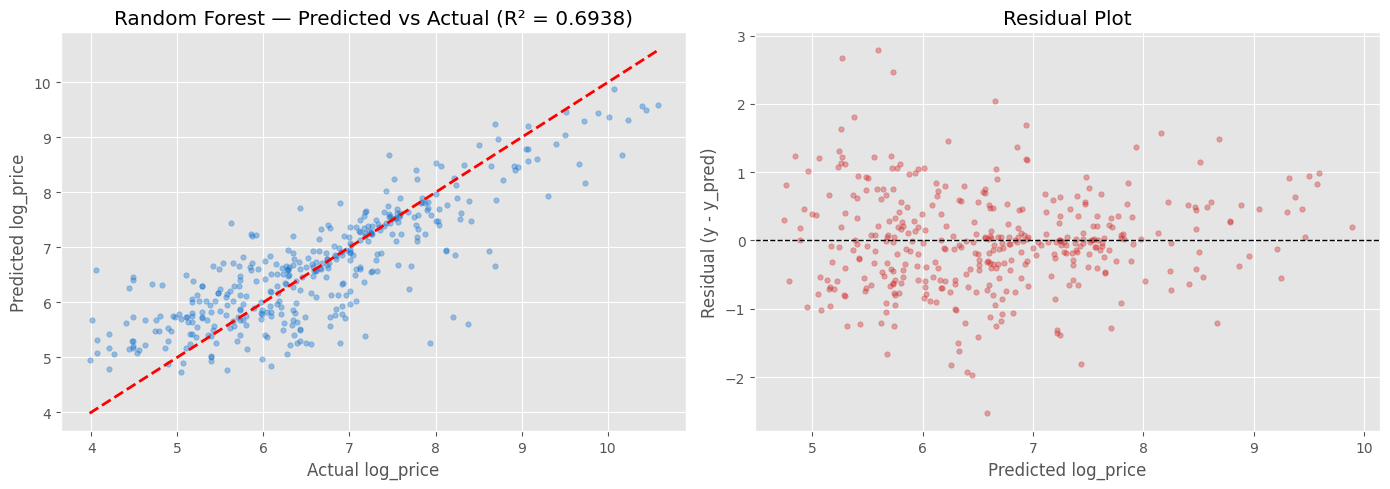

In [365]:

y_pred_log_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_log_rf)

mae_rf = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_log_rf))
rmse_rf = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log_rf)))
mape_rf = np.mean(np.abs((np.expm1(y_test) - np.expm1(y_pred_log_rf)) / np.expm1(y_test))) * 100

print(f'Random Forest')
print(f'R² test: {r2_rf:.4f}')
print(f'MAE: {mae_rf:.2f} RON')
print(f'RMSE: {rmse_rf:.2f} RON')
print(f'MAPE: {mape_rf:.2f}%')

fig, axes_rf = plt.subplots(1, 2, figsize=(14, 5))

axes_rf[0].scatter(y_test, y_pred_log_rf, alpha=0.4, s=15, color='#1976D2')
min_val_rf = min(y_test.min(), y_pred_log_rf.min())
max_val_rf = max(y_test.max(), y_pred_log_rf.max())
axes_rf[0].plot([min_val_rf, max_val_rf], [min_val_rf, max_val_rf], 'r--', linewidth=2)
axes_rf[0].set_xlabel('Actual log_price')
axes_rf[0].set_ylabel('Predicted log_price')
axes_rf[0].set_title(f'Random Forest — Predicted vs Actual (R² = {r2_rf:.4f})')

residuals_rf = y_test - y_pred_log_rf
axes_rf[1].scatter(y_pred_log_rf, residuals_rf, alpha=0.4, s=15, color='#D32F2F')
axes_rf[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes_rf[1].set_xlabel('Predicted log_price')
axes_rf[1].set_ylabel('Residual (y - y_pred)')
axes_rf[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

# 4.3 Gradient Boost


Gradient Boosting
R² test: 0.6717
MAE: 943.93 RON
RMSE: 2780.43 RON
MAPE: 71.15%


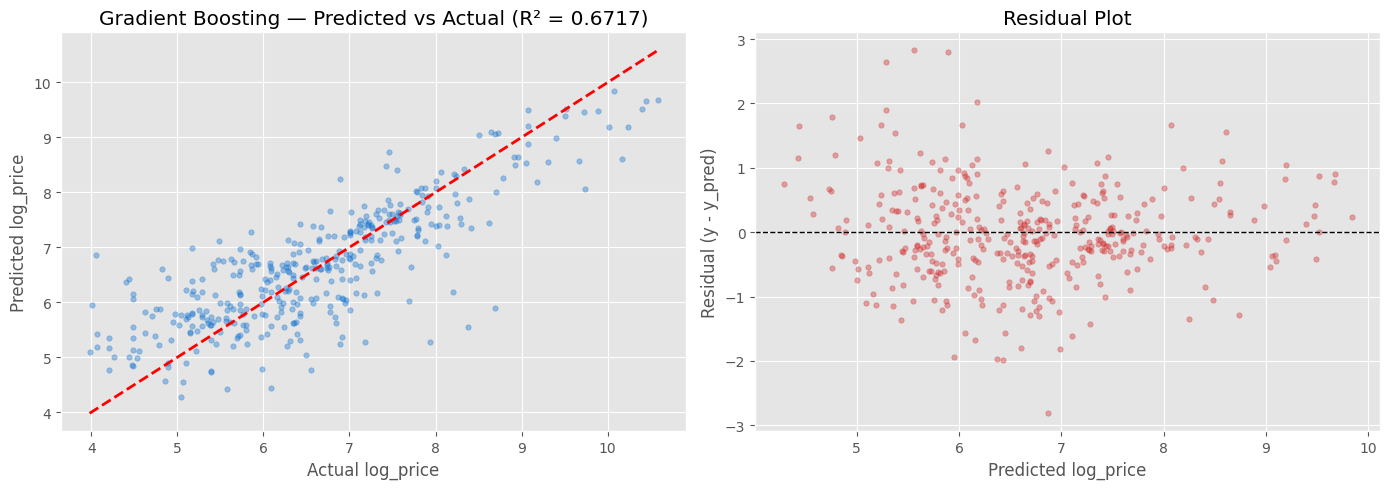

In [366]:
y_pred_log_gb = gb.predict(X_test)

r2_gb = r2_score(y_test, y_pred_log_gb)
mae_gb = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_log_gb))
rmse_gb = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log_gb)))
mape_gb = np.mean(np.abs((np.expm1(y_test) - np.expm1(y_pred_log_gb)) / np.expm1(y_test))) * 100

print(f'Gradient Boosting')
print(f'R² test: {r2_gb:.4f}')
print(f'MAE: {mae_gb:.2f} RON')
print(f'RMSE: {rmse_gb:.2f} RON')
print(f'MAPE: {mape_gb:.2f}%')

fig, axes_gb = plt.subplots(1, 2, figsize=(14, 5))

axes_gb[0].scatter(y_test, y_pred_log_gb, alpha=0.4, s=15, color='#1976D2')
min_val_gb = min(y_test.min(), y_pred_log_gb.min())
max_val_gb = max(y_test.max(), y_pred_log_gb.max())
axes_gb[0].plot([min_val_gb, max_val_gb], [min_val_gb, max_val_gb], 'r--', linewidth=2)
axes_gb[0].set_xlabel('Actual log_price')
axes_gb[0].set_ylabel('Predicted log_price')
axes_gb[0].set_title(f'Gradient Boosting — Predicted vs Actual (R² = {r2_gb:.4f})')

residuals_gb = y_test - y_pred_log_gb
axes_gb[1].scatter(y_pred_log_gb, residuals_gb, alpha=0.4, s=15, color='#D32F2F')
axes_gb[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes_gb[1].set_xlabel('Predicted log_price')
axes_gb[1].set_ylabel('Residual (y - y_pred)')
axes_gb[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

### 4.4 Importanta caracteristicilor la XGBoost

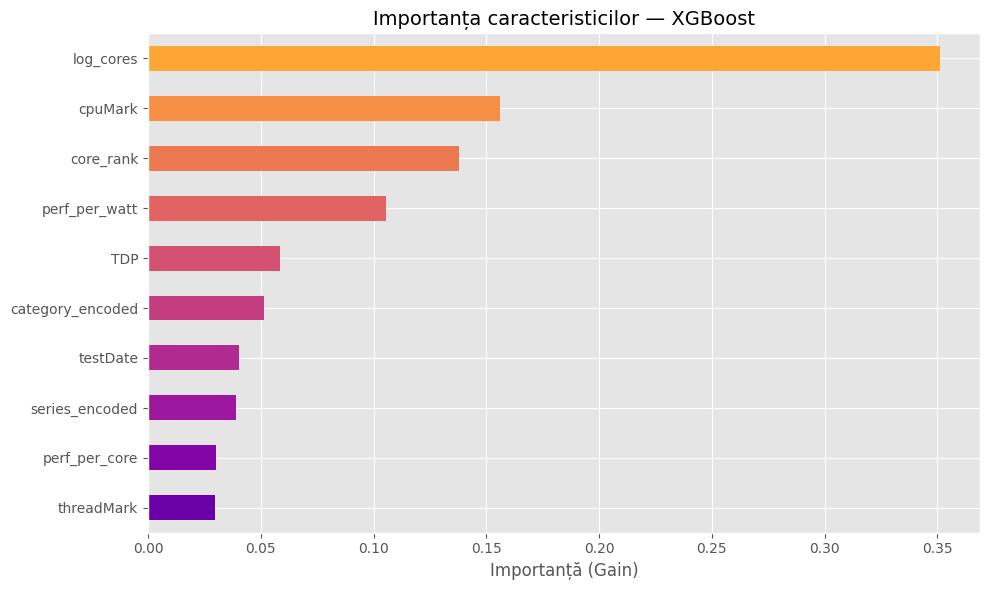

In [367]:
feature_cols = ['cpuMark', 'threadMark', 'TDP',
                'perf_per_core', 'perf_per_watt',
                'core_rank', 'log_cores',
                'series_encoded', 'category_encoded',
                'testDate']

df_model = df_fe.dropna()
X = df_model[feature_cols]
y = df_model['log_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=33550336
)

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=33550336,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train, y_train)

importances_xgb = pd.Series(xgb_model.feature_importances_, index=feature_cols)
importances_xgb = importances_xgb.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(importances_xgb)))
importances_xgb.plot(kind='barh', color=colors)
plt.title('Importanța caracteristicilor — XGBoost', fontsize=14)
plt.xlabel('Importanță (Gain)')
plt.tight_layout()
plt.show()


# 4.4 XGBoost

XGBoost
R² test: 0.6988
MAE: 954.71 RON
RMSE: 2881.49 RON
MAPE: 66.83%


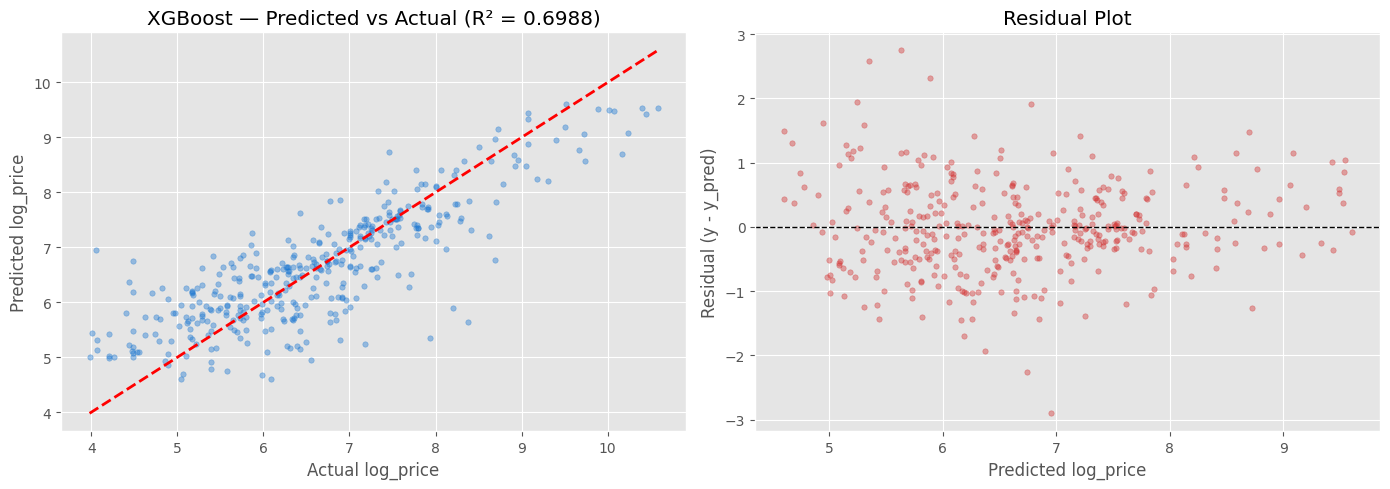

In [368]:
y_pred_log_xgb = xgb_model.predict(X_test)

r2_xgb = r2_score(y_test, y_pred_log_xgb)
mae_xgb = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_log_xgb))
rmse_xgb = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log_xgb)))
mape_xgb = np.mean(np.abs((np.expm1(y_test) - np.expm1(y_pred_log_xgb)) / np.expm1(y_test))) * 100

print(f'XGBoost')
print(f'R² test: {r2_xgb:.4f}')
print(f'MAE: {mae_xgb:.2f} RON')
print(f'RMSE: {rmse_xgb:.2f} RON')
print(f'MAPE: {mape_xgb:.2f}%')

fig, axes_xgb = plt.subplots(1, 2, figsize=(14, 5))

axes_xgb[0].scatter(y_test, y_pred_log_xgb, alpha=0.4, s=15, color='#1976D2')
min_val_xgb = min(y_test.min(), y_pred_log_xgb.min())
max_val_xgb = max(y_test.max(), y_pred_log_xgb.max())
axes_xgb[0].plot([min_val_xgb, max_val_xgb], [min_val_xgb, max_val_xgb], 'r--', linewidth=2)
axes_xgb[0].set_xlabel('Actual log_price')
axes_xgb[0].set_ylabel('Predicted log_price')
axes_xgb[0].set_title(f'XGBoost — Predicted vs Actual (R² = {r2_xgb:.4f})')

residuals_xgb = y_test - y_pred_log_xgb
axes_xgb[1].scatter(y_pred_log_xgb, residuals_xgb, alpha=0.4, s=15, color='#D32F2F')
axes_xgb[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes_xgb[1].set_xlabel('Predicted log_price')
axes_xgb[1].set_ylabel('Residual (y - y_pred)')
axes_xgb[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

# 5. Optimizarea hiperparametrilor
### 5.1 Optimizarea regresiei liniare Ridge

In [369]:
param_grid_ridge = {
    # Generează valori precum 0.01, 0.1, 1, 10, 100, 1000
    'alpha': np.linspace(0, 100, 2000) 
}

ridge_gs = Ridge(random_state=33550336)
grid_ridge = GridSearchCV(
    ridge_gs, param_grid_ridge, cv=5,
    scoring='r2', n_jobs=-1
)

grid_ridge.fit(X_train_s, y_train)
print(f'Best alpha: {grid_ridge.best_params_["alpha"]}')
print(f'Best CV R²: {grid_ridge.best_score_:.4f}')

best_ridge = grid_ridge.best_estimator_
y_pred_log_ridge_gs = best_ridge.predict(X_test_s)

r2_ridge_gs = r2_score(y_test, y_pred_log_ridge_gs)
mae_ridge_gs = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_log_ridge_gs))
rmse_ridge_gs = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log_ridge_gs)))
mape_ridge_gs = np.mean(np.abs((np.expm1(y_test) - np.expm1(y_pred_log_ridge_gs)) / np.expm1(y_test))) * 100

print(f'Test R²: {r2_ridge_gs:.4f} (before: {r2_ridge:.4f})')
print(f'Test MAE: {mae_ridge_gs:.2f} RON (before: {mae_ridge:.2f})')

Best alpha: 25.012506253126563
Best CV R²: 0.5415
Test R²: 0.5997 (before: 0.5982)
Test MAE: 1092.03 RON (before: 1092.16)


### 5.2 Optimizarea Random Forest

In [370]:
# param_grid_rf = {
#     "n_estimators": [200, 500, 1000],
#     "max_depth": [10, 20, 30, 40, None],
#     "min_samples_split": [2, 5, 10],
#     "min_samples_leaf": [1, 2, 4],
#     "max_features": ["sqrt", "log2", 0.5, 0.8],
# }

# rf_gs = RandomForestRegressor(random_state=33550336, n_jobs=-1)
# grid_rf = GridSearchCV(
#     rf_gs, param_grid_rf, cv=5,
#     scoring='r2', n_jobs=-1
# )

# grid_rf.fit(X_train, y_train)

# print(f'Best params: {grid_rf.best_params_}')
# print(f'Best CV R²: {grid_rf.best_score_:.4f}')

# best_rf = grid_rf.best_estimator_
# y_pred_log_rf_gs = best_rf.predict(X_test)

# r2_rf_gs = r2_score(y_test, y_pred_log_rf_gs)
# mae_rf_gs = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_log_rf_gs))
# rmse_rf_gs = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log_rf_gs)))
# mape_rf_gs = np.mean(np.abs((np.expm1(y_test) - np.expm1(y_pred_log_rf_gs)) / np.expm1(y_test))) * 100

# print(f'Test R²: {r2_rf_gs:.4f} (before: {r2_rf:.4f})')
# print(f'Test MAE: {mae_rf_gs:.2f} RON (before: {mae_rf:.2f})')

### 5.3 Optimizare gradiant boosting

In [371]:
param_grid_gb = {
    'n_estimators': [200, 500, 1000, 1500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 8, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'max_features': ['sqrt', 'log2', 0.8]
}
gb_random = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=33550336),
    param_distributions=param_grid_gb,
    n_iter=60,         
    cv=5, 
    scoring='r2', 
    verbose=2, 
    n_jobs=-1,         
    random_state=33550336
)
gb_random.fit(X_train, y_train)

print(f'Best params: {gb_random.best_params_}')
print(f'Best CV R²: {gb_random.best_score_:.4f}')

best_gb = gb_random.best_estimator_

y_pred_log_gb_gs = best_gb.predict(X_test)
r2_gb_gs = r2_score(y_test, y_pred_log_gb_gs)
mae_gb_gs = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_log_gb_gs))
rmse_gb_gs = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log_gb_gs)))
mape_gb_gs = np.mean(np.abs((np.expm1(y_test) - np.expm1(y_pred_log_gb_gs)) / np.expm1(y_test))) * 100

print(f'Test R²: {r2_gb_gs:.4f} (before: {r2_gb:.4f})')
print(f'Test MAE: {mae_gb_gs:.2f} RON (before: {mae_gb:.2f})')

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best params: {'subsample': 0.7, 'n_estimators': 500, 'max_features': 'log2', 'max_depth': 5, 'learning_rate': 0.01}
Best CV R²: 0.6596
Test R²: 0.7036 (before: 0.6717)
Test MAE: 914.93 RON (before: 943.93)
